# **DATA** **PREPARATION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from torchvision.transforms import InterpolationMode

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root='/content/drive/MyDrive/Dataset/Training',
    transform=transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,     # ⭐ Smaller batch improves detail learning
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)

Batch shape: torch.Size([32, 1, 128, 128])


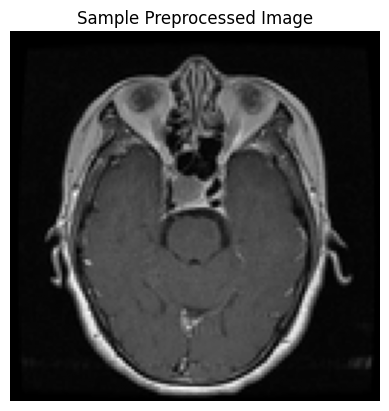

In [ ]:
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title("Sample Preprocessed Image")
plt.axis('off')
plt.show()

# **ENCODER**

In [ ]:
class Encoder(nn.Module):

    def __init__(self, latent_dim=256):

        super(Encoder, self).__init__()

        self.conv_layers = nn.Sequential(

            # 128 → 64
            nn.Conv2d(1,32,4,2,1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            # 64 → 32
            nn.Conv2d(32,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            # 32 → 16
            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # ⭐ NEW 16 → 8
            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )

        self.flatten = nn.Flatten()

        self.fc_mu = nn.Linear(256*8*8, latent_dim)
        self.fc_logvar = nn.Linear(256*8*8, latent_dim)


    def reparameterize(self,mu,logvar):

        logvar = torch.clamp(logvar,-10,10)

        std = torch.exp(0.5*logvar)

        eps = torch.randn_like(std)

        return mu + std*eps


    def forward(self,x):

        x = self.conv_layers(x)

        x = self.flatten(x)

        mu = self.fc_mu(x)

        logvar = self.fc_logvar(x)

        z = self.reparameterize(mu,logvar)

        return mu,logvar,z

In [ ]:
encoder = Encoder(latent_dim=256)

encoder.eval()

with torch.no_grad():

    sample_batch, _ = next(iter(train_loader))

    mu, logvar, z = encoder(sample_batch)

    print("Input shape:", sample_batch.shape)
    print("Mu shape:", mu.shape)
    print("Logvar shape:", logvar.shape)
    print("Latent z shape:", z.shape)

Input shape: torch.Size([32, 1, 128, 128])
Mu shape: torch.Size([32, 256])
Logvar shape: torch.Size([32, 256])
Latent z shape: torch.Size([32, 256])


# **Decoder**

In [ ]:
import torch
import torch.nn as nn

class Decoder(nn.Module):

    def __init__(self, latent_dim=256):

        super(Decoder, self).__init__()

        # Expand latent vector
        self.fc = nn.Linear(latent_dim, 128 * 16 * 16)


        self.deconv_layers = nn.Sequential(

            # 16 → 32
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # Feature refinement ⭐
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            # 32 → 64
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            # Feature refinement ⭐
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            # 64 → 128
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),

            # Final sharpening layer ⭐
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),

            nn.Sigmoid()
        )


    def forward(self, z):

        x = self.fc(z)

        x = x.view(-1, 128, 16, 16)

        x = self.deconv_layers(x)

        return x

In [ ]:
decoder = Decoder(latent_dim=256)

# Take z from encoder
sample_batch, _ = next(iter(train_loader))
mu, logvar, z = encoder(sample_batch)

reconstructed = decoder(z)

print("Reconstructed shape:", reconstructed.shape)

Reconstructed shape: torch.Size([32, 1, 128, 128])


In [ ]:
print(reconstructed.min().item())
print(reconstructed.max().item())

0.10063658654689789
0.881581723690033


# **Full** **VAE** **Model**

In [ ]:
class VAE(nn.Module):

    def __init__(self, latent_dim=256):

        super(VAE, self).__init__()

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

        self.latent_dim = latent_dim


    def forward(self, x):

        mu, logvar, z = self.encoder(x)

        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar


    # ⭐ Generate synthetic MRI images
    def generate(self, num_samples, device):

        z = torch.randn(num_samples, self.latent_dim).to(device)

        images = self.decoder(z)

        return images

In [ ]:
vae = VAE(latent_dim=256)

sample_batch, _ = next(iter(train_loader))
reconstructed, mu, logvar = vae(sample_batch)

print("Input shape:", sample_batch.shape)
print("Reconstructed shape:", reconstructed.shape)
print("Mu shape:", mu.shape)
print("Logvar shape:", logvar.shape)

Input shape: torch.Size([32, 1, 128, 128])
Reconstructed shape: torch.Size([32, 1, 128, 128])
Mu shape: torch.Size([32, 256])
Logvar shape: torch.Size([32, 256])


# **ELBO** **Loss**

In [ ]:
import torch.nn.functional as F

def vae_loss_function(reconstructed, original, mu, logvar):

    batch_size = original.size(0)

    # ⭐ Sharper than MSE
    recon_loss = F.l1_loss(
        reconstructed,
        original,
        reduction='sum'
    ) / batch_size

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / batch_size

    # ⭐ Smaller KL weight = sharper images
    beta = 0.0005

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
sample_batch, _ = next(iter(train_loader))
reconstructed, mu, logvar = vae(sample_batch)

total_loss, recon_loss, kl_loss = vae_loss_function(
    reconstructed, sample_batch, mu, logvar
)

print("Total loss:", total_loss.item())
print("Reconstruction loss:", recon_loss.item())
print("KL loss:", kl_loss.item())

Total loss: 6545.201171875
Reconstruction loss: 6545.18359375
KL loss: 34.68125534057617


# **TRAINING** **LOOP**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

vae = VAE(latent_dim=256).to(device)

Using device: cuda


Define Optimizer

In [ ]:
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

Epoch [1/60] Total: 93.1089 | Recon: 93.0885 | KL: 40.8117
Epoch [2/60] Total: 37.3641 | Recon: 37.3361 | KL: 55.9033
Epoch [3/60] Total: 25.3256 | Recon: 25.2907 | KL: 69.8364
Epoch [4/60] Total: 22.9823 | Recon: 22.9456 | KL: 73.4572
Epoch [5/60] Total: 22.0210 | Recon: 21.9800 | KL: 81.9473
Epoch [6/60] Total: 21.2639 | Recon: 21.2258 | KL: 76.2002
Epoch [7/60] Total: 20.5814 | Recon: 20.5429 | KL: 76.8725
Epoch [8/60] Total: 19.9170 | Recon: 19.8784 | KL: 77.1902
Epoch [9/60] Total: 19.5055 | Recon: 19.4671 | KL: 76.7922
Epoch [10/60] Total: 19.3083 | Recon: 19.2697 | KL: 77.2857


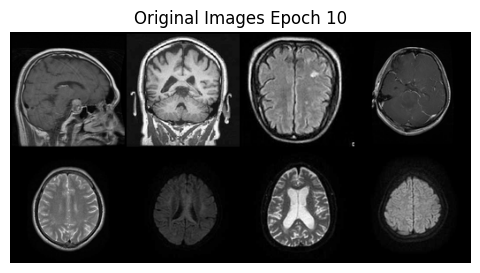

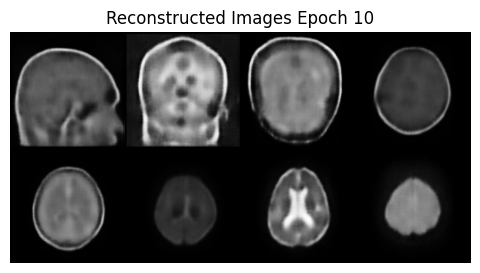

Epoch [11/60] Total: 18.9796 | Recon: 18.9402 | KL: 78.8330
Epoch [12/60] Total: 18.5510 | Recon: 18.5109 | KL: 80.3298
Epoch [13/60] Total: 18.4789 | Recon: 18.4381 | KL: 81.5314
Epoch [14/60] Total: 18.2034 | Recon: 18.1625 | KL: 81.7849
Epoch [15/60] Total: 18.0333 | Recon: 17.9920 | KL: 82.5572
Epoch [16/60] Total: 17.7842 | Recon: 17.7382 | KL: 91.9851
Epoch [17/60] Total: 17.6267 | Recon: 17.5846 | KL: 84.0562
Epoch [18/60] Total: 17.3851 | Recon: 17.3427 | KL: 84.8060
Epoch [19/60] Total: 17.3388 | Recon: 17.2961 | KL: 85.4734
Epoch [20/60] Total: 17.1204 | Recon: 17.0774 | KL: 85.9838


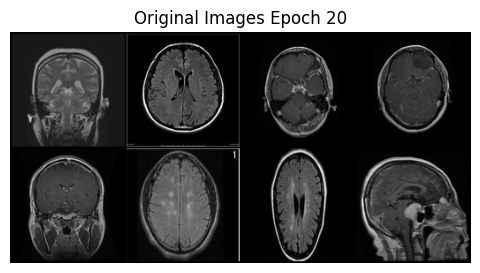

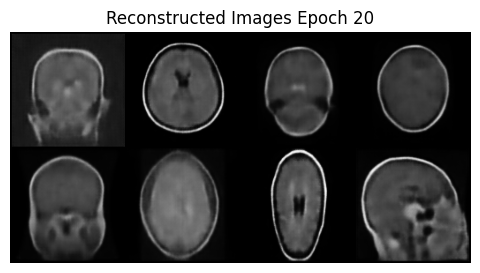

Epoch [21/60] Total: 17.0789 | Recon: 17.0344 | KL: 88.9369
Epoch [22/60] Total: 17.1771 | Recon: 17.1024 | KL: 149.2291
Epoch [23/60] Total: 16.8392 | Recon: 16.7948 | KL: 88.8024
Epoch [24/60] Total: 16.7572 | Recon: 16.7127 | KL: 88.9363
Epoch [25/60] Total: 16.7378 | Recon: 16.6667 | KL: 142.0943
Epoch [26/60] Total: 16.5706 | Recon: 16.5249 | KL: 91.2597
Epoch [27/60] Total: 16.3727 | Recon: 16.3273 | KL: 90.7909
Epoch [28/60] Total: 16.4179 | Recon: 16.3721 | KL: 91.4970
Epoch [29/60] Total: 16.1069 | Recon: 16.0604 | KL: 93.0231
Epoch [30/60] Total: 16.0299 | Recon: 15.9833 | KL: 93.0758


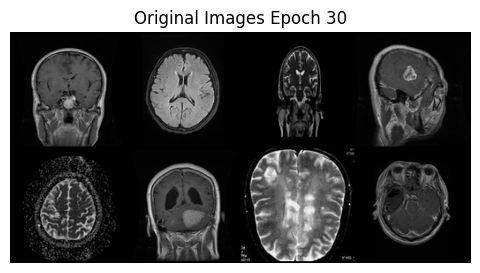

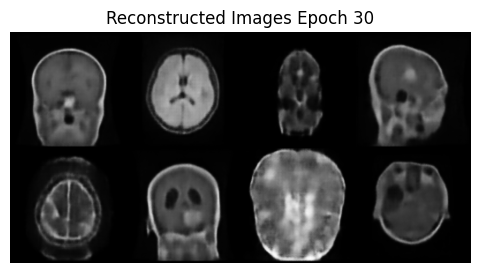

Epoch [31/60] Total: 16.0516 | Recon: 16.0050 | KL: 93.1927
Epoch [32/60] Total: 16.1067 | Recon: 16.0589 | KL: 95.5463
Epoch [33/60] Total: 15.8954 | Recon: 15.8479 | KL: 95.0736
Epoch [34/60] Total: 15.7728 | Recon: 15.7255 | KL: 94.5705
Epoch [35/60] Total: 15.8205 | Recon: 15.7728 | KL: 95.4878
Epoch [36/60] Total: 15.8154 | Recon: 15.7677 | KL: 95.3311
Epoch [37/60] Total: 15.5483 | Recon: 15.5000 | KL: 96.5148
Epoch [38/60] Total: 15.5300 | Recon: 15.4812 | KL: 97.7623
Epoch [39/60] Total: 15.3871 | Recon: 15.3387 | KL: 96.9163
Epoch [40/60] Total: 15.5341 | Recon: 15.4853 | KL: 97.6681


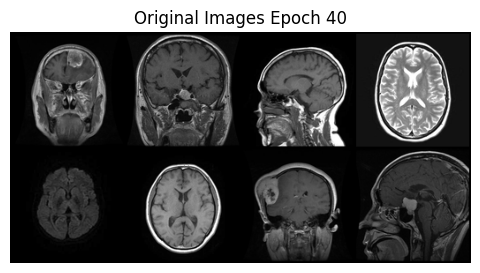

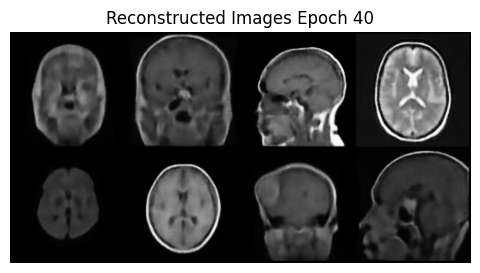

Epoch [41/60] Total: 15.4658 | Recon: 15.4164 | KL: 98.7328
Epoch [42/60] Total: 15.1698 | Recon: 15.1209 | KL: 97.8420
Epoch [43/60] Total: 15.1227 | Recon: 15.0732 | KL: 98.9988
Epoch [44/60] Total: 15.0269 | Recon: 14.9771 | KL: 99.4644
Epoch [45/60] Total: 15.1023 | Recon: 15.0525 | KL: 99.5863
Epoch [46/60] Total: 15.0592 | Recon: 15.0090 | KL: 100.5355
Epoch [47/60] Total: 14.9044 | Recon: 14.8084 | KL: 191.9161
Epoch [48/60] Total: 14.8953 | Recon: 14.8448 | KL: 101.1069
Epoch [49/60] Total: 14.8197 | Recon: 14.7659 | KL: 107.6221
Epoch [50/60] Total: 14.8047 | Recon: 14.7537 | KL: 102.0040


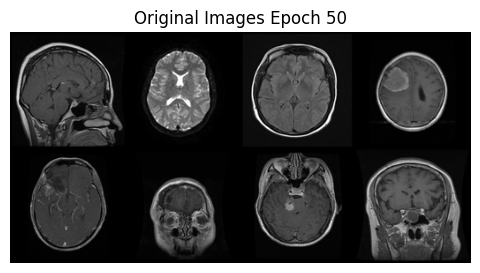

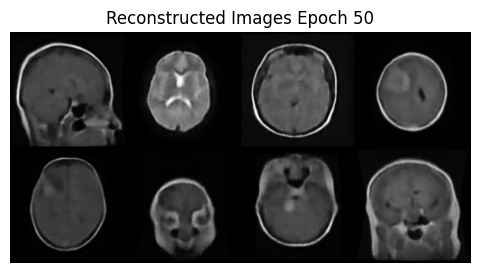

Epoch [51/60] Total: 14.7215 | Recon: 14.6705 | KL: 102.0750
Epoch [52/60] Total: 14.6306 | Recon: 14.5796 | KL: 102.0047
Epoch [53/60] Total: 14.6332 | Recon: 14.5741 | KL: 118.2766
Epoch [54/60] Total: 14.4022 | Recon: 14.3506 | KL: 103.1040
Epoch [55/60] Total: 14.5745 | Recon: 14.5226 | KL: 103.8499
Epoch [56/60] Total: 14.2629 | Recon: 14.2110 | KL: 103.8879
Epoch [57/60] Total: 14.2565 | Recon: 14.2046 | KL: 103.9463
Epoch [58/60] Total: 14.2601 | Recon: 14.2039 | KL: 112.4156
Epoch [59/60] Total: 14.4425 | Recon: 14.3899 | KL: 105.3548
Epoch [60/60] Total: 14.1795 | Recon: 14.1266 | KL: 105.7389


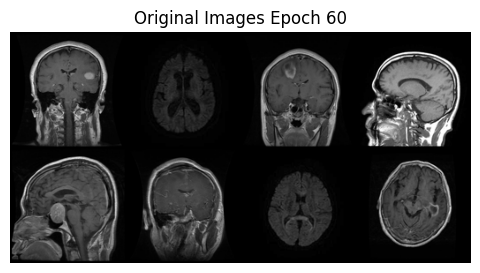

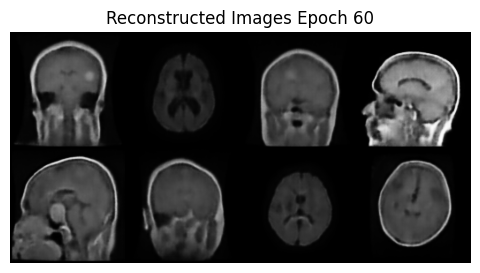

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

num_epochs = 60   # ⭐ Better than 100 for stability

for epoch in range(num_epochs):

    vae.train()

    train_loss = 0
    train_recon = 0
    train_kl = 0

    for images, _ in train_loader:

        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = vae(images)

        total_loss, recon_loss, kl_loss = vae_loss_function(
            reconstructed, images, mu, logvar
        )

        total_loss.backward()

        # ⭐ Prevent KL explosion
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)

        optimizer.step()

        train_loss += total_loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()


    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = train_recon / len(train_loader.dataset)
    avg_kl = train_kl / len(train_loader.dataset)


    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Total: {avg_loss:.4f} | "
          f"Recon: {avg_recon:.4f} | "
          f"KL: {avg_kl:.4f}")


    # ⭐ Show images every 10 epochs
    if (epoch+1) % 10 == 0:

        vae.eval()

        with torch.no_grad():

            sample_images, _ = next(iter(train_loader))
            sample_images = sample_images.to(device)

            reconstructed, _, _ = vae(sample_images)

            # Original images
            plt.figure(figsize=(6,3))
            plt.title(f"Original Images Epoch {epoch+1}")
            plt.imshow(
                vutils.make_grid(
                    sample_images[:8].cpu(),
                    nrow=4,
                    normalize=True   # ⭐ Better contrast
                ).permute(1,2,0)
            )
            plt.axis("off")
            plt.show()


            # Reconstructed images
            plt.figure(figsize=(6,3))
            plt.title(f"Reconstructed Images Epoch {epoch+1}")
            plt.imshow(
                vutils.make_grid(
                    reconstructed[:8].cpu(),
                    nrow=4,
                    normalize=True   # ⭐ Sharper display
                ).permute(1,2,0)
            )
            plt.axis("off")
            plt.show()

In [ ]:
torch.save(vae.state_dict(), "vae_epoch60.pth")

print("Model saved as vae_epoch60.pth")

Model saved as vae_epoch60.pth


# **Reconstruction & Synthetic Image Generation**

In [ ]:




vae.load_state_dict(torch.load("vae_epoch60.pth"))
vae.eval()

print("Loaded Epoch 60 model")

Loaded Epoch 60 model


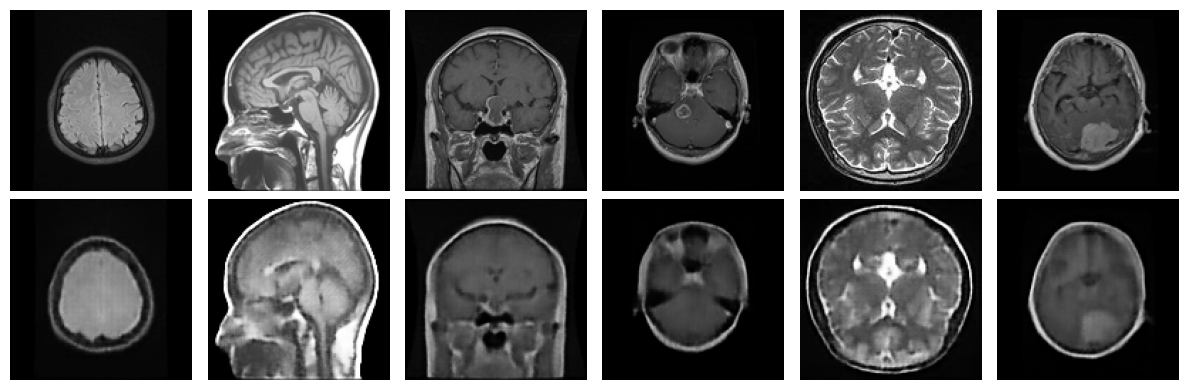

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

vae.load_state_dict(torch.load("vae_epoch60.pth"))
vae.eval()

images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed, _, _ = vae(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

# ⭐ Sharpen reconstructed images
reconstructed = TF.adjust_sharpness(reconstructed, 2.5)

num_images = 6

plt.figure(figsize=(12,4))

for i in range(num_images):

    plt.subplot(2,num_images,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')

    plt.subplot(2,num_images,i+1+num_images)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')

plt.tight_layout()
plt.show()

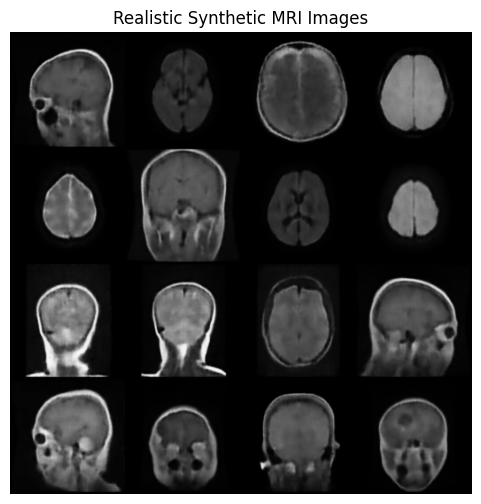

In [ ]:
vae.eval()

with torch.no_grad():

    # Take real images
    images, _ = next(iter(train_loader))
    images = images.to(device)

    # Encode them
    mu, logvar, z = vae.encoder(images)

    # Slight variation ⭐
    z = z + 0.1 * torch.randn_like(z)

    # Decode
    generated = vae.decoder(z).cpu()

plt.figure(figsize=(6,6))

plt.imshow(
    vutils.make_grid(generated[:16], nrow=4).permute(1,2,0),
    cmap='gray'
)

plt.axis("off")
plt.title("Realistic Synthetic MRI Images")
plt.show()

Loaded Epoch 60 model
Epoch [61/100] Total: 14.1912 | Recon: 14.1386 | KL: 105.0863
Epoch [62/100] Total: 14.1230 | Recon: 14.0705 | KL: 104.9536
Epoch [63/100] Total: 14.2218 | Recon: 14.1690 | KL: 105.7408
Epoch [64/100] Total: 13.9736 | Recon: 13.9208 | KL: 105.6048
Epoch [65/100] Total: 13.9508 | Recon: 13.8973 | KL: 106.9576
Epoch [66/100] Total: 13.8385 | Recon: 13.7848 | KL: 107.3659
Epoch [67/100] Total: 13.8687 | Recon: 13.8151 | KL: 107.2868
Epoch [68/100] Total: 13.9217 | Recon: 13.8681 | KL: 107.1118
Epoch [69/100] Total: 13.9332 | Recon: 13.8762 | KL: 114.1608
Epoch [70/100] Total: 13.6648 | Recon: 13.6107 | KL: 108.1961
Saved Model: vae_epoch70.pth


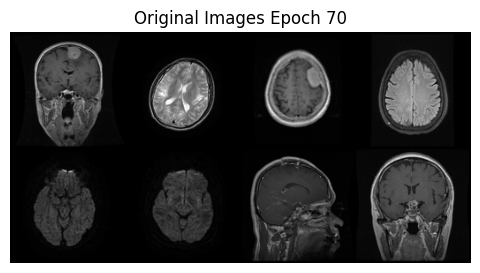

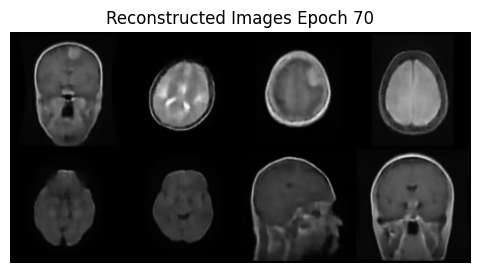

Epoch [71/100] Total: 13.6312 | Recon: 13.5773 | KL: 107.8603
Epoch [72/100] Total: 25.5915 | Recon: 13.5740 | KL: 24034.9798
Epoch [73/100] Total: 13.4986 | Recon: 13.4404 | KL: 116.3130
Epoch [74/100] Total: 13.5557 | Recon: 13.5014 | KL: 108.4869
Epoch [75/100] Total: 13.4823 | Recon: 13.4280 | KL: 108.6541
Epoch [76/100] Total: 13.5702 | Recon: 13.5041 | KL: 132.0465
Epoch [77/100] Total: 13.3390 | Recon: 13.2549 | KL: 168.2048
Epoch [78/100] Total: 13.2567 | Recon: 13.2024 | KL: 108.5882
Epoch [79/100] Total: 13.3060 | Recon: 13.2513 | KL: 109.3795
Epoch [80/100] Total: 13.1754 | Recon: 13.1206 | KL: 109.5093
Saved Model: vae_epoch80.pth


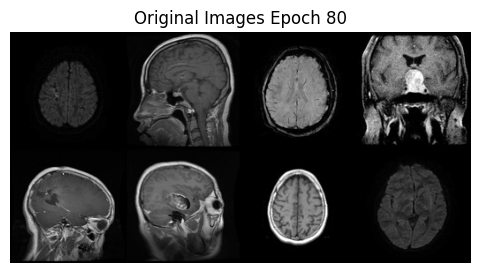

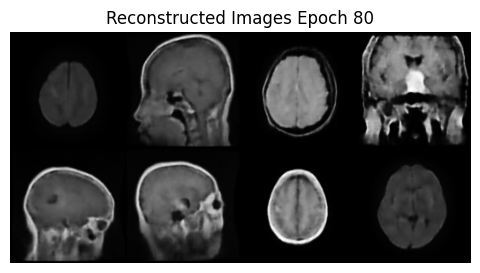

Epoch [81/100] Total: 13.3157 | Recon: 13.2593 | KL: 112.7155
Epoch [82/100] Total: 13.2832 | Recon: 13.2282 | KL: 110.1016
Epoch [83/100] Total: 13.1161 | Recon: 13.0612 | KL: 109.8602
Epoch [84/100] Total: 13.1251 | Recon: 13.0701 | KL: 109.9798
Epoch [85/100] Total: 13.0096 | Recon: 12.9542 | KL: 110.8140
Epoch [86/100] Total: 13.0469 | Recon: 12.9914 | KL: 110.9058
Epoch [87/100] Total: 12.9414 | Recon: 12.8861 | KL: 110.4743
Epoch [88/100] Total: 12.9786 | Recon: 12.9231 | KL: 111.0405
Epoch [89/100] Total: 12.8616 | Recon: 12.8061 | KL: 111.0675
Epoch [90/100] Total: 12.9155 | Recon: 12.8582 | KL: 114.5999
Saved Model: vae_epoch90.pth


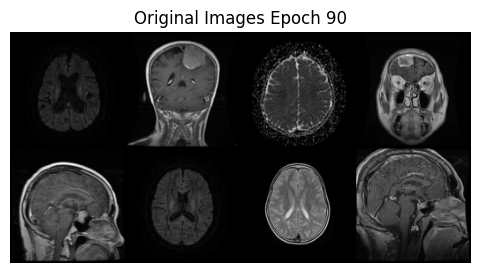

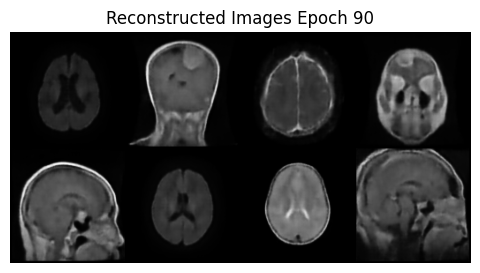

Epoch [91/100] Total: 12.8038 | Recon: 12.7450 | KL: 117.6710
Epoch [92/100] Total: 12.8595 | Recon: 12.8022 | KL: 114.6138
Epoch [93/100] Total: 12.7072 | Recon: 12.6515 | KL: 111.2291
Epoch [94/100] Total: 12.6251 | Recon: 12.5693 | KL: 111.4174
Epoch [95/100] Total: 12.5844 | Recon: 12.5289 | KL: 111.0975
Epoch [96/100] Total: 12.6218 | Recon: 12.5663 | KL: 110.9487
Epoch [97/100] Total: 12.6057 | Recon: 12.5503 | KL: 110.8195
Epoch [98/100] Total: 12.5558 | Recon: 12.4978 | KL: 116.0557
Epoch [99/100] Total: 12.6205 | Recon: 12.5649 | KL: 111.2541
Epoch [100/100] Total: 12.3970 | Recon: 12.2287 | KL: 336.4453
Saved Model: vae_epoch100.pth


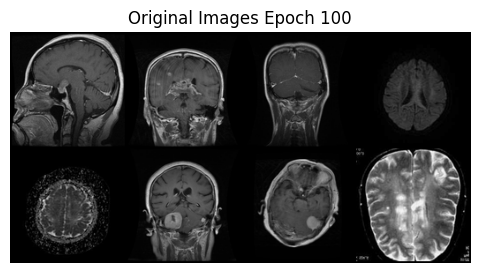

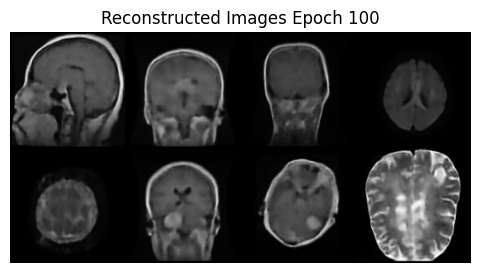

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torch

# ⭐ Load Epoch 60 model first
vae.load_state_dict(torch.load("vae_epoch60.pth"))
print("Loaded Epoch 60 model")

start_epoch = 60
num_epochs = 100   # ⭐ Total epochs


for epoch in range(start_epoch, num_epochs):

    vae.train()

    train_loss = 0
    train_recon = 0
    train_kl = 0

    for images, _ in train_loader:

        images = images.to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = vae(images)

        total_loss, recon_loss, kl_loss = vae_loss_function(
            reconstructed, images, mu, logvar
        )

        total_loss.backward()

        # ⭐ Prevent KL explosion
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)

        optimizer.step()

        train_loss += total_loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()


    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = train_recon / len(train_loader.dataset)
    avg_kl = train_kl / len(train_loader.dataset)


    print(f"Epoch [{epoch+1}/100] "
          f"Total: {avg_loss:.4f} | "
          f"Recon: {avg_recon:.4f} | "
          f"KL: {avg_kl:.4f}")


    # ⭐ Save Ablation Models
    if (epoch+1) in [70,80,90,100]:

        torch.save(
            vae.state_dict(),
            f"vae_epoch{epoch+1}.pth"
        )

        print(f"Saved Model: vae_epoch{epoch+1}.pth")


    # ⭐ Show images every 10 epochs
    if (epoch+1) % 10 == 0:

        vae.eval()

        with torch.no_grad():

            sample_images, _ = next(iter(train_loader))
            sample_images = sample_images.to(device)

            reconstructed, _, _ = vae(sample_images)

            # Original images
            plt.figure(figsize=(6,3))
            plt.title(f"Original Images Epoch {epoch+1}")

            plt.imshow(
                vutils.make_grid(
                    sample_images[:8].cpu(),
                    nrow=4,
                    normalize=True
                ).permute(1,2,0)
            )

            plt.axis("off")
            plt.show()


            # Reconstructed images
            plt.figure(figsize=(6,3))
            plt.title(f"Reconstructed Images Epoch {epoch+1}")

            plt.imshow(
                vutils.make_grid(
                    reconstructed[:8].cpu(),
                    nrow=4,
                    normalize=True
                ).permute(1,2,0)
            )

            plt.axis("off")
            plt.show()